In [105]:
import os
from pyhere import here

os.chdir(here())
from sdm.utils.logging_utils import setup_logging
import logging

setup_logging(level=logging.INFO)

# Set working directory to project root
from pathlib import Path

In [106]:
import pandas as pd
from pathlib import Path
import rioxarray as rxr
import xarray as xr


In [107]:
# Load the EV data
ev_folder = Path("data/evs/")
boundary_path = Path("data/processed/boundary.geojson")


# Try to load the merged dataset first
merged_path = ev_folder / "all-evs.tif"


ev_stack = rxr.open_rasterio(merged_path, masked=True, band_as_variable=True)

# rename bands

name_mapping = {
    ev_stack[var].name: ev_stack[var].attrs["long_name"] for var in ev_stack.data_vars
}

ev_stack = ev_stack.rename(name_mapping)

ev_stack

<xarray.Dataset> Size: 727MB
Dimensions:                               (x: 1930, y: 1544)
Coordinates:
  * x                                     (x) float64 15kB 3.562e+05 ... 5.49...
  * y                                     (y) float64 12kB 3.716e+05 ... 5.26...
    spatial_ref                           int64 8B 0
Data variables: (12/61)
    ceh_landcover_broadleaved_woodland    (y, x) float32 12MB ...
    ceh_landcover_coniferous_woodland     (y, x) float32 12MB ...
    ceh_landcover_arable                  (y, x) float32 12MB ...
    ceh_landcover_improved_grassland      (y, x) float32 12MB ...
    ceh_landcover_urban                   (y, x) float32 12MB ...
    ceh_landcover_suburban                (y, x) float32 12MB ...
    ...                                    ...
    climate_bioclim_bio_15                (y, x) float32 12MB ...
    climate_bioclim_bio_16                (y, x) float32 12MB ...
    climate_bioclim_bio_17                (y, x) float32 12MB ...
    climate_bioclim_bio_18                (y, x) float32 12MB ...
    climate_bioclim_bio_19                (y, x) float32 12MB ...
    bgs_coast_distance_to_coast           (y, x) float32 12MB ...
Attributes:
    AREA_OR_POINT:  Area

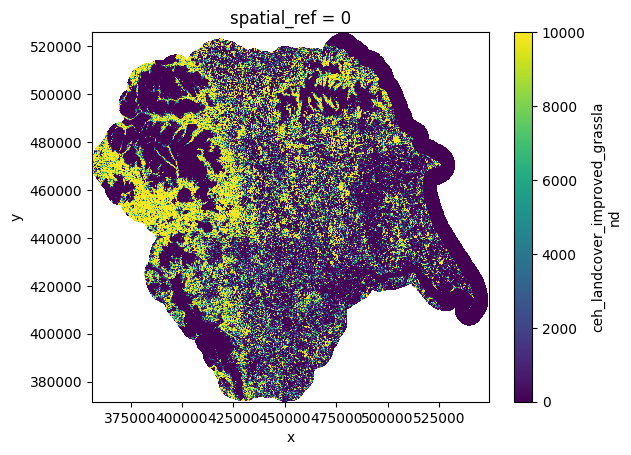

In [108]:
ev_stack["ceh_landcover_improved_grassland"].plot()

# Run some Checks

In [109]:
ev_df = ev_stack.to_dataframe()
ev_df.head()

spatial_ref  ceh_landcover_broadleaved_woodland  \
x        y                                                           
356250.0 371650.0            0                                 NaN   
         371750.0            0                                 NaN   
         371850.0            0                                 NaN   
         371950.0            0                                 NaN   
         372050.0            0                                 NaN   

                   ceh_landcover_coniferous_woodland  ceh_landcover_arable  \
x        y                                                                   
356250.0 371650.0                                NaN                   NaN   
         371750.0                                NaN                   NaN   
         371850.0                                NaN                   NaN   
         371950.0                                NaN                   NaN   
         372050.0                                NaN                   NaN   

                   ceh_landcover_improved_grassland  ceh_landcover_urban  \
x        y                                                                 
356250.0 371650.0                               NaN                  NaN   
         371750.0                               NaN                  NaN   
         371850.0                               NaN                  NaN   
         371950.0                               NaN                  NaN   
         372050.0                               NaN                  NaN   

                   ceh_landcover_suburban  ceh_landcover_grassland  \
x        y                                                           
356250.0 371650.0                     NaN                      NaN   
         371750.0                     NaN                      NaN   
         371850.0                     NaN                      NaN   
         371950.0                     NaN                      NaN   
         372050.0                     NaN                      NaN   

                   ceh_landcover_upland_heathland  ceh_landcover_wetland  ...  \
x        y                                                                ...   
356250.0 371650.0                             NaN                    NaN  ...   
         371750.0                             NaN                    NaN  ...   
         371850.0                             NaN                    NaN  ...   
         371950.0                             NaN                    NaN  ...   
         372050.0                             NaN                    NaN  ...   

                   climate_bioclim_bio_11  climate_bioclim_bio_12  \
x        y                                                          
356250.0 371650.0                     NaN                     NaN   
         371750.0                     NaN                     NaN   
         371850.0                     NaN                     NaN   
         371950.0                     NaN                     NaN   
         372050.0                     NaN                     NaN   

                   climate_bioclim_bio_13  climate_bioclim_bio_14  \
x        y                                                          
356250.0 371650.0                     NaN                     NaN   
         371750.0                     NaN                     NaN   
         371850.0                     NaN                     NaN   
         371950.0                     NaN                     NaN   
         372050.0                     NaN                     NaN   

                   climate_bioclim_bio_15  climate_bioclim_bio_16  \
x        y                                                          
356250.0 371650.0                     NaN                     NaN   
         371750.0                     NaN                     NaN   
         371850.0                     NaN                     NaN   
         371950.0                     NaN                     NaN   
       

In [110]:
ev_df.drop(columns=["spatial_ref"], inplace=True)

## Missing Values

There should be some missing values where I've clipped the data using a buffer but it should be less than 45%.

In [111]:
# Count the missing values per variable and sor tin descending order
baseline_missing: float = 0.45
ev_df.isna().mean().sort_values(ascending=False).to_frame(
    name="missing_fraction"
).query("missing_fraction > @baseline_missing")

,missing_fraction


## Visualise some of the missing values


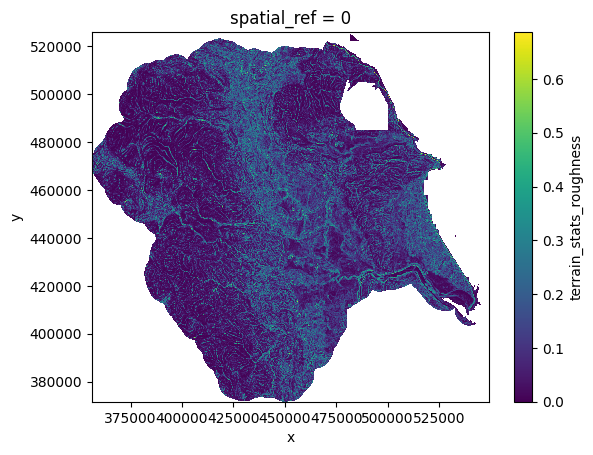

In [112]:
ev_stack["terrain_stats_roughness"].plot()

Where are the missing values in the dataset?

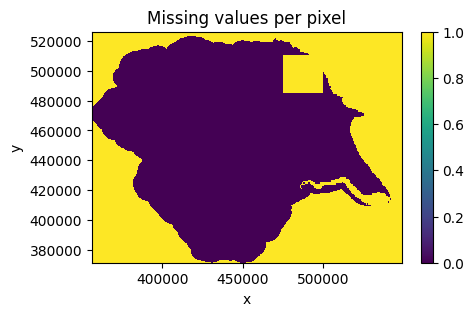

In [113]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 3))
np.isnan(ev_stack.to_array()).any(axis=0).plot(ax=ax)
# add title
ax.set_title("Missing values per pixel")

plt.show()


# Visualise the EV Distributions


/var/folders/w6/z6wv9w5s4r77c8m0lp63lm1w0000gp/T/ipykernel_68347/3673652731.py:17: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


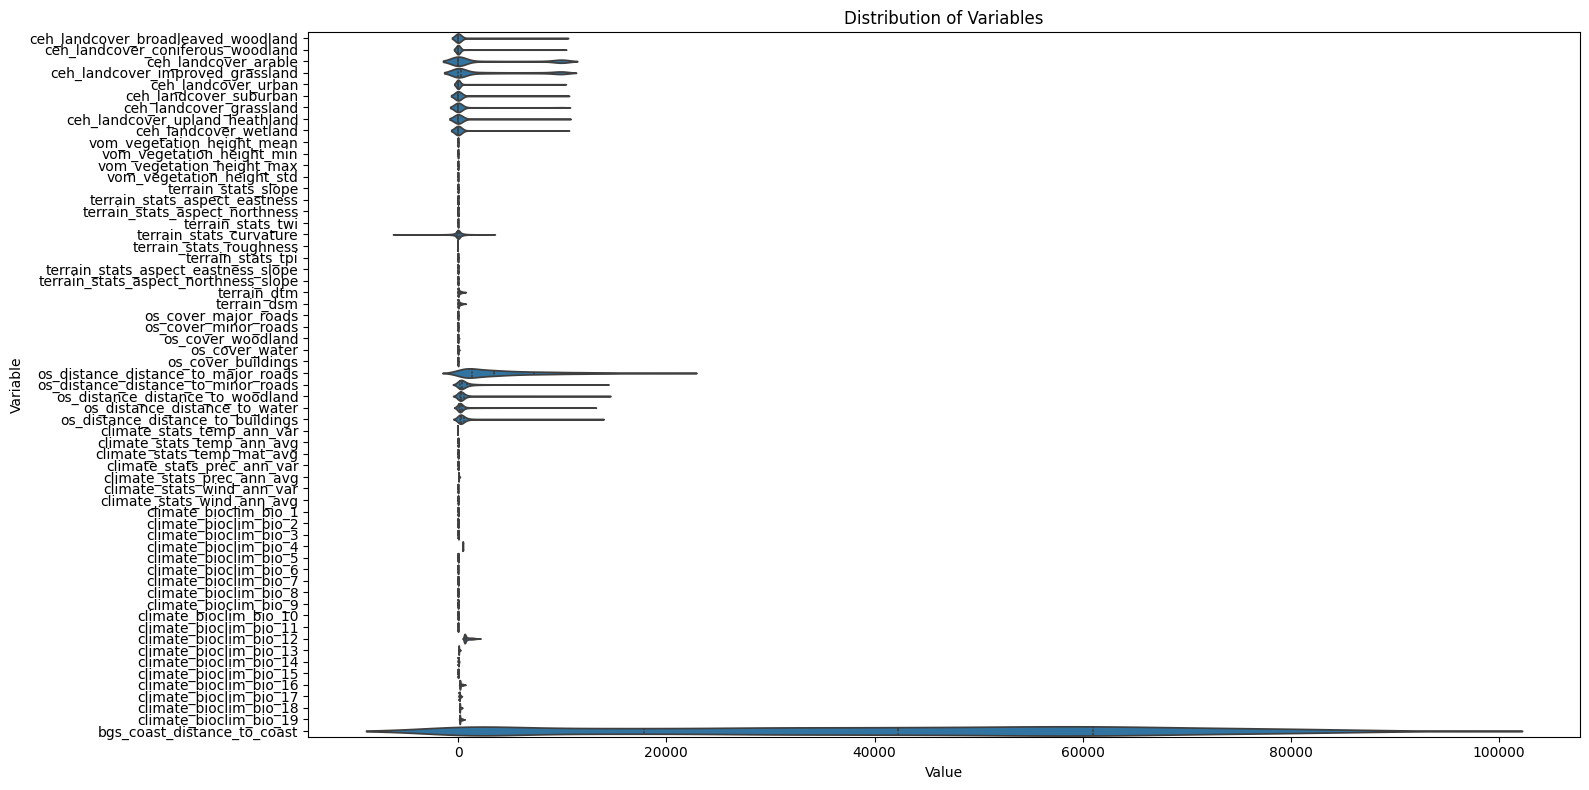

In [114]:
import seaborn as sns

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# Melt the DataFrame to long format for seaborn
ev_df_melted = (
    ev_df.reset_index()
    .sample(10_000)
    .melt(id_vars=["x", "y"], var_name="Variable", value_name="Value")
)

# Create the violin plot
plt.figure(figsize=(16, 8))
sns.violinplot(
    data=ev_df_melted, y="Variable", x="Value", scale="width", inner="quartile"
)

plt.title("Distribution of Variables")
plt.tight_layout()
plt.show()

In [115]:
ev_df.sample(10_000).describe().T

,count,mean,std,min,25%,50%,75%,max
ceh_landcover_broadleaved_woodland,6292.0,484.186279,1581.503418,0.000000,0.000000,0.000000,0.000000,10000.000000
ceh_landcover_coniferous_woodland,6292.0,175.286072,1115.577148,0.000000,0.000000,0.000000,0.000000,10000.000000
ceh_landcover_arable,6292.0,2737.841797,4096.949707,0.000000,0.000000,0.000000,6500.000000,10000.000000
ceh_landcover_improved_grassland,6292.0,3019.469238,3904.770264,0.000000,0.000000,400.000000,6500.000000,10000.000000
ceh_landcover_urban,6292.0,246.980286,1161.821289,0.000000,0.000000,0.000000,0.000000,10000.000000
...,...,...,...,...,...,...,...,...
climate_bioclim_bio_16,5796.0,271.592072,118.332390,145.000000,181.239410,220.368408,348.599182,679.932007
climate_bioclim_bio_17,5796.0,179.166214,53.200855,115.471748,135.725403,160.197113,216.197754,354.643982
climate_bioclim_bio_18,5796.0,204.343765,59.199219,144.868469,160.479614,175.837402,239.812576,399.697906
climate_bioclim_bio_19,5796.0,245.485611,105.287933,132.001053,162.854309,201.297668,316.411957,614.133850


In [116]:
list(ev_stack.data_vars)

['ceh_landcover_broadleaved_woodland',
 'ceh_landcover_coniferous_woodland',
 'ceh_landcover_arable',
 'ceh_landcover_improved_grassland',
 'ceh_landcover_urban',
 'ceh_landcover_suburban',
 'ceh_landcover_grassland',
 'ceh_landcover_upland_heathland',
 'ceh_landcover_wetland',
 'vom_vegetation_height_mean',
 'vom_vegetation_height_min',
 'vom_vegetation_height_max',
 'vom_vegetation_height_std',
 'terrain_stats_slope',
 'terrain_stats_aspect_eastness',
 'terrain_stats_aspect_northness',
 'terrain_stats_twi',
 'terrain_stats_curvature',
 'terrain_stats_roughness',
 'terrain_stats_tpi',
 'terrain_stats_aspect_eastness_slope',
 'terrain_stats_aspect_northness_slope',
 'terrain_dtm',
 'terrain_dsm',
 'os_cover_major_roads',
 'os_cover_minor_roads',
 'os_cover_woodland',
 'os_cover_water',
 'os_cover_buildings',
 'os_distance_distance_to_major_roads',
 'os_distance_distance_to_minor_roads',
 'os_distance_distance_to_woodland',
 'os_distance_distance_to_water',
 'os_distance_distance_to_bui

### Scale some distributions

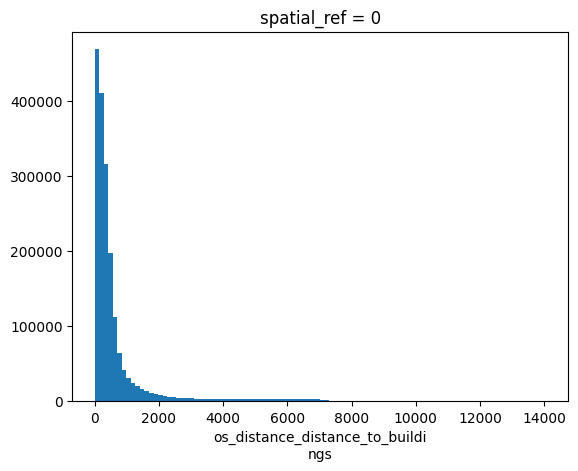

In [117]:
_ = ev_stack["os_distance_distance_to_buildings"].plot.hist(bins=100)

In [118]:
# distance to coast - clip to 0 - 7000
ev_stack["bgs_coast_distance_to_coast"] = ev_stack["bgs_coast_distance_to_coast"].clip(
    0, 7000
)
# clip terrain_stats_curvature to 5-95%
p_95 = ev_stack["terrain_stats_curvature"].quantile(0.95)
p_5 = ev_stack["terrain_stats_curvature"].quantile(0.05)
ev_stack["terrain_stats_curvature"] = ev_stack["terrain_stats_curvature"].clip(
    p_5, p_95
)

# clip os_distance_distance_to_buildings to 0-7000
ev_stack["os_distance_distance_to_buildings"] = ev_stack[
    "os_distance_distance_to_buildings"
].clip(0, 7000)
ev_stack["os_distance_distance_to_major_roads"] = ev_stack[
    "os_distance_distance_to_major_roads"
].clip(0, 7000)


# Calculate EV Correlations

In [119]:
ev_df.dropna(inplace=True)

ev_correlations = ev_df.sample(10_000).corr()
ev_correlations.head()

,ceh_landcover_broadleaved_woodland,ceh_landcover_coniferous_woodland,ceh_landcover_arable,ceh_landcover_improved_grassland,ceh_landcover_urban,ceh_landcover_suburban,ceh_landcover_grassland,ceh_landcover_upland_heathland,ceh_landcover_wetland,vom_vegetation_height_mean,...,climate_bioclim_bio_11,climate_bioclim_bio_12,climate_bioclim_bio_13,climate_bioclim_bio_14,climate_bioclim_bio_15,climate_bioclim_bio_16,climate_bioclim_bio_17,climate_bioclim_bio_18,climate_bioclim_bio_19,bgs_coast_distance_to_coast
ceh_landcover_broadleaved_woodland,1.000000,0.061678,-0.175495,-0.057941,-0.053711,-0.055944,-0.088919,-0.085825,-0.076495,0.705183,...,0.092080,-0.092979,-0.089785,-0.087723,-0.060752,-0.089711,-0.086675,-0.100252,-0.087568,0.051966
ceh_landcover_coniferous_woodland,0.061678,1.000000,-0.100324,-0.084025,-0.032226,-0.045751,-0.022452,-0.001414,-0.028706,0.457127,...,-0.103483,0.085211,0.083170,0.088933,0.085437,0.084713,0.086753,0.085608,0.084208,0.018574
ceh_landcover_arable,-0.175495,-0.100324,1.000000,-0.450955,-0.139185,-0.227754,-0.231565,-0.221451,-0.185688,-0.193186,...,0.398746,-0.508388,-0.511254,-0.513561,-0.545444,-0.513245,-0.518035,-0.494290,-0.517950,-0.324472
ceh_landcover_improved_grassland,-0.057941,-0.084025,-0.450955,1.000000,-0.123361,-0.140963,-0.202125,-0.202537,-0.206570,-0.004460,...,0.136612,-0.044900,-0.041953,-0.045877,0.058055,-0.038603,-0.045002,-0.043867,-0.046457,0.084844
ceh_landcover_urban,-0.053711,-0.032226,-0.139185,-0.123361,1.000000,0.208975,-0.073790,-0.069021,-0.058379,-0.046841,...,0.176845,-0.103014,-0.095886,-0.105222,-0.073615,-0.098439,-0.097776,-0.113816,-0.094583,0.038176


Some of the correlations ar NA because the values are all 0 in the dataset. This is where that land cover feature doesn't exist inland and should just be converted to NA.

In [120]:
ev_correlations.fillna(0, inplace=True)

/var/folders/w6/z6wv9w5s4r77c8m0lp63lm1w0000gp/T/ipykernel_68347/2219842834.py:7: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = hierarchy.linkage(distance, method="ward")


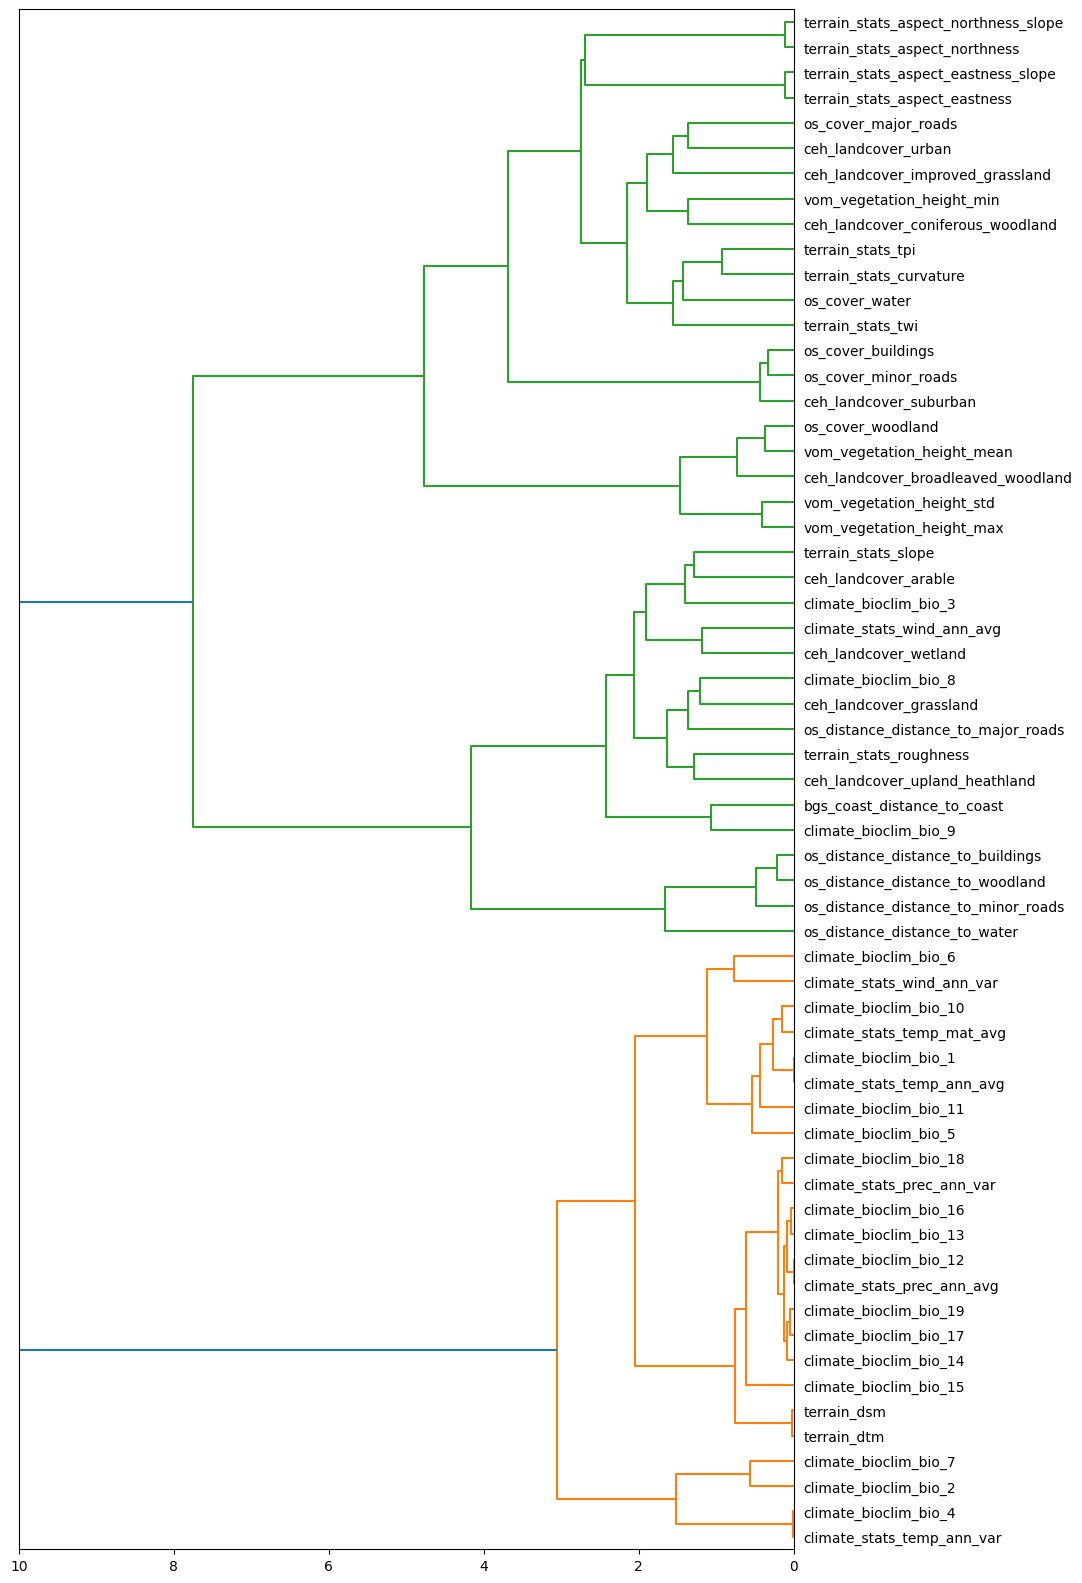

In [121]:
from scipy.cluster import hierarchy

# Calculate distance between each variable (1 - correlation to have a sense of distance)
distance = 1 - ev_correlations.abs()

# Perform hierarchical clustering
linkage_matrix = hierarchy.linkage(distance, method="ward")

plt.figure(figsize=(10, 20))
hierarchy.dendrogram(
    linkage_matrix,
    labels=ev_correlations.columns.tolist(),
    orientation="left",
    leaf_font_size=10,
)
plt.xlim(10, 0)
plt.show()

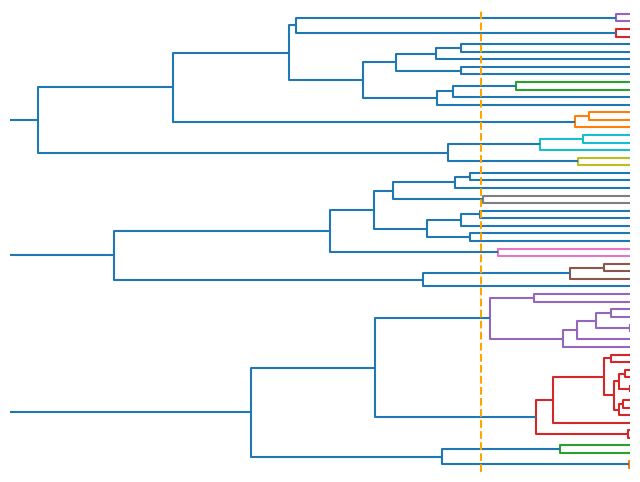

In [122]:
plt.figure(figsize=(8, 6))

cut_height = 1.2
hierarchy.dendrogram(
    linkage_matrix,
    no_labels=True,
    orientation="left",
    color_threshold=cut_height,
)
# add a vertical line to mark the threshold
plt.axvline(x=cut_height, color="orange", linestyle="--")
plt.xlim(5, 0)
# drop the panel
plt.gca().set_axis_off()
background_color = "#eeeeee"
# set panel background color
plt.gca().patch.set_facecolor(background_color)
plt.show()

In [123]:
# Cluster the samples
cluster_ids = hierarchy.fcluster(linkage_matrix, t=1.2, criterion="distance")

# Create a DataFrame to see clusters
column_clusters = pd.DataFrame(
    {"cluster_id": cluster_ids, "column_name": ev_df.columns}
)
print(column_clusters.cluster_id.value_counts().sort_index())

cluster_id
1      2
2      2
3     12
4      8
5      3
6      1
7      2
8      1
9      1
10     1
11     1
12     1
13     2
14     1
15     1
16     1
17     2
18     3
19     3
20     2
21     1
22     1
23     1
24     1
25     1
26     1
27     1
28     2
29     2
Name: count, dtype: int64


In [124]:
column_clusters = column_clusters.sort_values("cluster_id")
column_clusters.to_csv("data/evs/ev_clusters.csv", index=False)

In [125]:
selected_var_path = Path("data/ev_clusters_selected.csv")

# Check if the file exists
assert selected_var_path.exists(), (
    f"File {selected_var_path} does not exist. Please run the clustering script and select EVs first."
)

selectecd_vars_df = pd.read_csv(selected_var_path)

keep_evs = selectecd_vars_df[selectecd_vars_df["include"] == 1].column_name.tolist()
print(keep_evs)

['climate_stats_temp_ann_var', 'climate_bioclim_bio_4', 'climate_bioclim_bio_7', 'climate_bioclim_bio_2', 'climate_stats_prec_ann_var', 'terrain_dtm', 'climate_stats_prec_ann_avg', 'climate_stats_temp_ann_avg', 'climate_stats_temp_mat_avg', 'ceh_landcover_wetland', 'os_distance_distance_to_buildings', 'os_distance_distance_to_minor_roads', 'climate_bioclim_bio_9', 'bgs_coast_distance_to_coast', 'ceh_landcover_upland_heathland', 'terrain_stats_roughness', 'ceh_landcover_grassland', 'climate_bioclim_bio_8', 'os_distance_distance_to_major_roads', 'ceh_landcover_arable', 'terrain_stats_slope', 'climate_stats_wind_ann_avg', 'climate_bioclim_bio_3', 'vom_vegetation_height_max', 'vom_vegetation_height_std', 'ceh_landcover_broadleaved_woodland', 'vom_vegetation_height_mean', 'ceh_landcover_suburban', 'os_cover_buildings', 'terrain_stats_tpi', 'os_cover_water', 'terrain_stats_twi', 'ceh_landcover_coniferous_woodland', 'ceh_landcover_urban', 'ceh_landcover_improved_grassland', 'os_distance_dista

In [126]:
# Subset the xr dataset to  only include the variables with the keep evs names
evs_to_model = ev_stack[keep_evs]
evs_to_model

<xarray.Dataset> Size: 453MB
Dimensions:                               (y: 1544, x: 1930)
Coordinates:
  * x                                     (x) float64 15kB 3.562e+05 ... 5.49...
  * y                                     (y) float64 12kB 3.716e+05 ... 5.26...
    spatial_ref                           int64 8B 0
Data variables: (12/38)
    climate_stats_temp_ann_var            (y, x) float32 12MB nan nan ... nan
    climate_bioclim_bio_4                 (y, x) float32 12MB nan nan ... nan
    climate_bioclim_bio_7                 (y, x) float32 12MB nan nan ... nan
    climate_bioclim_bio_2                 (y, x) float32 12MB nan nan ... nan
    climate_stats_prec_ann_var            (y, x) float32 12MB nan nan ... nan
    terrain_dtm                           (y, x) float32 12MB nan nan ... nan
    ...                                    ...
    ceh_landcover_coniferous_woodland     (y, x) float32 12MB nan nan ... nan
    ceh_landcover_urban                   (y, x) float32 12MB nan nan ... nan
    ceh_landcover_improved_grassland      (y, x) float32 12MB nan nan ... nan
    os_distance_distance_to_water         (y, x) float32 12MB nan nan ... nan
    terrain_stats_aspect_northness_slope  (y, x) float32 12MB nan nan ... nan
    terrain_stats_aspect_eastness_slope   (y, x) float32 12MB nan nan ... nan
Attributes:
    AREA_OR_POINT:  Area

# Multi-Scale EVs

In [127]:
def calculate_multiscale_variables(dataset: xr.Dataset, window: int) -> xr.Dataset:
    original_names = dataset.data_vars

    vars = (
        dataset.rolling(x=window, y=window, center=True)
        .mean(skipna=True)
        .rename(
            {name: f"{name}_{round((window / 2) * 100)}m" for name in dataset.data_vars}
        )
    )
    # Assign nodata from the original dataset
    for new_name, old_name in zip(vars.data_vars, original_names):
        vars[new_name].rio.write_nodata(dataset[old_name].rio.nodata, inplace=True)
        vars[new_name].attrs["long_name"] = new_name

    return vars


In [128]:
resolution = 100  # m
windows = [10, 20, 30]  # 500, 1000, 1500


multiscale_groups = [
    "ceh_landcover",
    "os_cover_water",
]


multiscale_variables = [
    var
    for var in evs_to_model.data_vars
    if any([str(var).startswith(group) for group in multiscale_groups])
]

# Check the variable exists in the dataset
assert all([var in evs_to_model.data_vars for var in multiscale_variables])

# Calculate the average for each variable within the focal window
# and add the variable name as a suffix


# Calculate the multiscale variables for each window size
multiscale_datasets = [
    calculate_multiscale_variables(evs_to_model[multiscale_variables], window)
    for window in windows
]
multiscale_datasets = xr.merge(multiscale_datasets)

In [129]:
evs_multiscale = xr.merge([evs_to_model, multiscale_datasets])

# Write to output

In [130]:
evs_final = evs_multiscale


evs_final.rio.to_raster(
    "data/evs/evs-to-model.tif",
)

In [131]:
list(evs_final.data_vars)

['climate_stats_temp_ann_var',
 'climate_bioclim_bio_4',
 'climate_bioclim_bio_7',
 'climate_bioclim_bio_2',
 'climate_stats_prec_ann_var',
 'terrain_dtm',
 'climate_stats_prec_ann_avg',
 'climate_stats_temp_ann_avg',
 'climate_stats_temp_mat_avg',
 'ceh_landcover_wetland',
 'os_distance_distance_to_buildings',
 'os_distance_distance_to_minor_roads',
 'climate_bioclim_bio_9',
 'bgs_coast_distance_to_coast',
 'ceh_landcover_upland_heathland',
 'terrain_stats_roughness',
 'ceh_landcover_grassland',
 'climate_bioclim_bio_8',
 'os_distance_distance_to_major_roads',
 'ceh_landcover_arable',
 'terrain_stats_slope',
 'climate_stats_wind_ann_avg',
 'climate_bioclim_bio_3',
 'vom_vegetation_height_max',
 'vom_vegetation_height_std',
 'ceh_landcover_broadleaved_woodland',
 'vom_vegetation_height_mean',
 'ceh_landcover_suburban',
 'os_cover_buildings',
 'terrain_stats_tpi',
 'os_cover_water',
 'terrain_stats_twi',
 'ceh_landcover_coniferous_woodland',
 'ceh_landcover_urban',
 'ceh_landcover_impro